In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sanyasiraokoll/xiangon-new/Hyperspectral_XiongAn.hdr
/kaggle/input/datasets/sanyasiraokoll/xiangon-new/Farm_roi.hdr
/kaggle/input/datasets/sanyasiraokoll/xiangon-new/Hyperspectral_XiongAn.img
/kaggle/input/datasets/sanyasiraokoll/xiangon-new/Farm_roi.img
/kaggle/input/datasets/sanyasiraokoll/xiangon-new/Groundtruth.hdr
/kaggle/input/datasets/sanyasiraokoll/xiangon-new/Groundtruth.img


In [43]:
!pip install spectral -q

In [44]:
!pip show torch

Name: torch
Version: 2.10.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: cuda-bindings, filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvshmem-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, easyocr, fastai, kornia, peft, pytorch-ignite, pytorch-lightning, sentence-transformers, timm, torchaudio, torchdata, torchmetrics, torchvision


In [45]:
import os
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt

from spectral import open_image

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score
)

warnings.filterwarnings("ignore")

In [46]:
from spectral import open_image
import spectral

In [47]:
NUM_CLIENTS = 4

PATCH_SIZE = 128

# Paper = 0.40
# Kaggle Safe = 0.2
OVERLAP = 0.40
# Paper = 2000
# Kaggle Safe = 500
DIFFUSION_TIMESTEPS = 2000

# Paper = 500000 local epochs
# Kaggle Safe = 100
DIFFUSION_EPOCHS = 100

# Paper = 80
# Kaggle Safe = 30
UNMIX_EPOCHS = 80
NUM_ENDMEMBERS = 5

COMMUNICATION_ROUNDS = 4

LOCAL_CLASSIFIER_EPOCHS = 2

print("Parameters loaded")

Parameters loaded


In [48]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [49]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [50]:
os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("synthetic", exist_ok=True)

In [51]:
DATA_DIR = "/kaggle/input/datasets/sanyasiraokoll/xiangon-new"

HSI_HDR = f"{DATA_DIR}/Hyperspectral_XiongAn.hdr"
HSI_IMG = f"{DATA_DIR}/Hyperspectral_XiongAn.img"

GT_HDR = f"{DATA_DIR}/Groundtruth.hdr"
GT_IMG = f"{DATA_DIR}/Groundtruth.img"

In [52]:
print("Loading HSI...")

hsi = spectral.open_image(HSI_HDR)

X = hsi.load()

X = np.array(X).astype(np.float32)

print("HSI Shape :", X.shape)
print("Datatype  :", X.dtype)

Loading HSI...
HSI Shape : (1580, 3750, 256)
Datatype  : float32


In [53]:

import numpy as np

GT_HEIGHT = 1580
GT_WIDTH  = 3750

Y = np.fromfile(
    GT_IMG,
    dtype=np.uint8
)

Y = Y.reshape(
    GT_HEIGHT,
    GT_WIDTH
)

print("GT Shape:", Y.shape)

print("Unique Labels:")
print(np.unique(Y))

GT Shape: (1580, 3750)
Unique Labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [54]:
print("HSI Shape :", X.shape)
print("GT Shape  :", Y.shape)

print("Min Label :", Y.min())
print("Max Label :", Y.max())

print("Classes   :", np.unique(Y))

HSI Shape : (1580, 3750, 256)
GT Shape  : (1580, 3750)
Min Label : 0
Max Label : 19
Classes   : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [55]:
H,W,B = X.shape

print("="*50)

print("Height :", H)
print("Width  :", W)
print("Bands  :", B)

print("="*50)

print("Min :", X.min())
print("Max :", X.max())

print("="*50)

print("Number of Classes :", len(np.unique(Y))-1)

print("="*50)

Height : 1580
Width  : 3750
Bands  : 256
Min : 0.0
Max : 15422.0
Number of Classes : 19


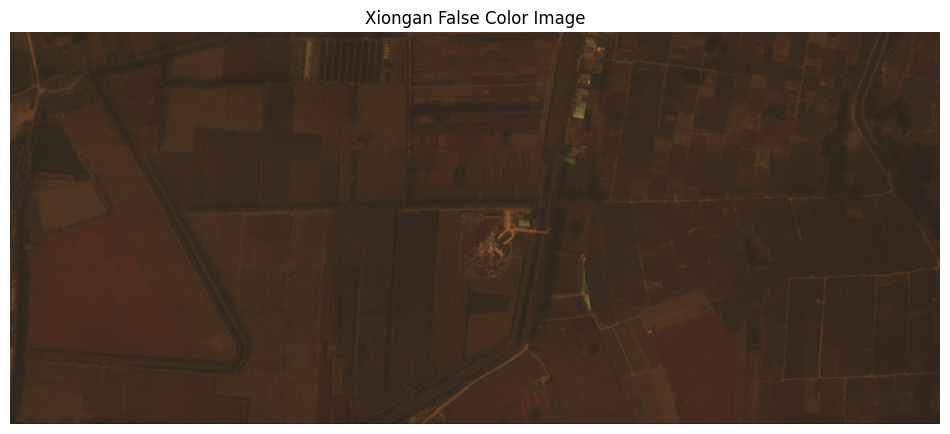

In [56]:
rgb = np.stack([
    X[:,:,60],
    X[:,:,30],
    X[:,:,10]
], axis=-1)

rgb = (rgb-rgb.min())/(rgb.max()-rgb.min())

plt.figure(figsize=(12,8))

plt.imshow(rgb)

plt.title("Xiongan False Color Image")

plt.axis("off")

plt.show()

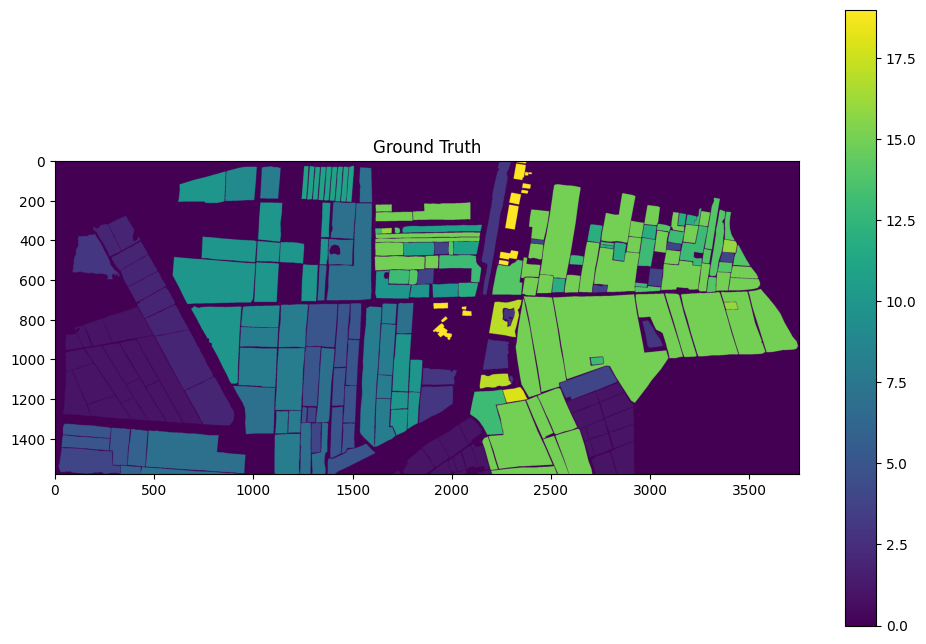

In [57]:
plt.figure(figsize=(12,8))

plt.imshow(Y)

plt.title("Ground Truth")

plt.colorbar()

plt.show()

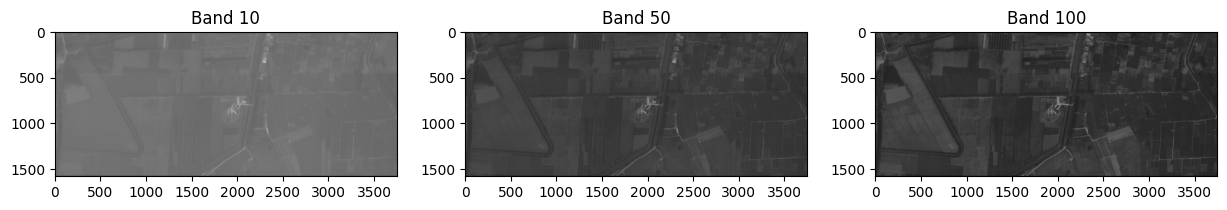

In [58]:
plt.figure(figsize=(15,5))

for i,band in enumerate([10,50,100]):
    plt.subplot(1,3,i+1)
    plt.imshow(X[:,:,band], cmap='gray')
    plt.title(f'Band {band}')

plt.show()

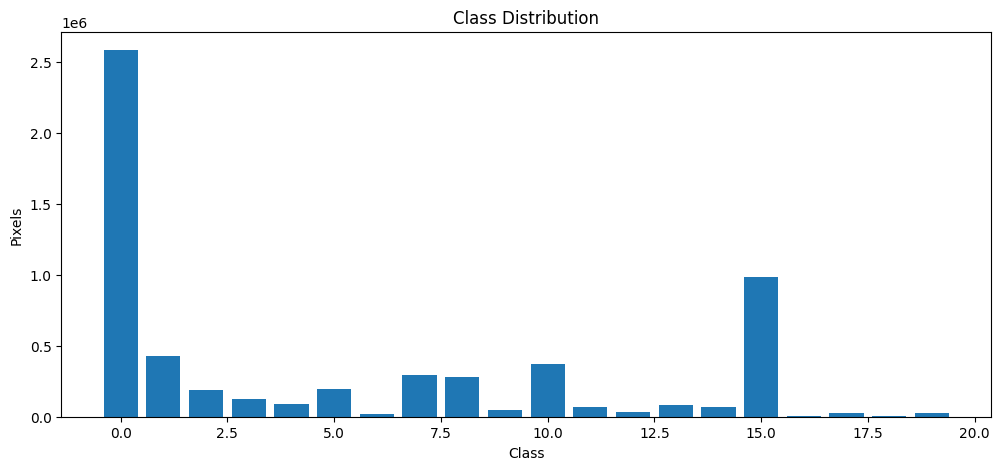

In [59]:
labels, counts = np.unique(Y, return_counts=True)

plt.figure(figsize=(12,5))
plt.bar(labels, counts)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Pixels")
plt.show()

In [60]:
# MEMORY SAFE NORMALIZATION

X = X.astype(np.float16)

X_min = X.min()
X_max = X.max()

X_norm = (X - X_min) / (X_max - X_min)

X_norm = X_norm.astype(np.float16)

print(X_norm.dtype)
print(X_norm.shape)

float16
(1580, 3750, 256)


In [61]:
print("Normalized Shape:", X_norm.shape)
print("Min:", X_norm.min())
print("Max:", X_norm.max())

Normalized Shape: (1580, 3750, 256)
Min: 0.0
Max: 1.0


In [62]:
print("="*60)
print("PHASE 1 COMPLETED")
print("="*60)

print("HSI Shape :", X.shape)
print("GT Shape  :", Y.shape)

print("Classes :", len(np.unique(Y))-1)

print("Ready for Patch Extraction")

PHASE 1 COMPLETED
HSI Shape : (1580, 3750, 256)
GT Shape  : (1580, 3750)
Classes : 19
Ready for Patch Extraction


In [63]:
# ==================================================
# CELL 21
# MEMORY OPTIMIZATION
# ==================================================

X_norm = X_norm.astype(np.float16)

print("Data Type :", X_norm.dtype)

memory_gb = X_norm.nbytes / (1024**3)

print(f"Memory Usage : {memory_gb:.2f} GB")

Data Type : float16
Memory Usage : 2.83 GB


In [64]:
# ==================================================
# CELL 22
# FREE MEMORY
#
# Paper:
# No memory restriction
#
# Kaggle Safe:
# Delete original HSI
# ==================================================

del X

import gc

gc.collect()

print("Original HSI Deleted")

Original HSI Deleted


In [65]:
# ==================================================
# CELL 23
# MEMORY CHECK
# ==================================================

memory_gb = X_norm.nbytes / (1024**3)

print(f"X_norm Memory = {memory_gb:.2f} GB")

X_norm Memory = 2.83 GB


In [66]:
# ==================================================
# CELL 24
# PATCH COORDINATES
#
# Paper:
# Overlap = 0.40
#
# Kaggle Safe:
# Overlap = 0.20
# ==================================================

stride = int(
    PATCH_SIZE * (1 - OVERLAP)
)

coords = []

H, W, B = X_norm.shape

for row in range(
    0,
    H - PATCH_SIZE + 1,
    stride
):

    for col in range(
        0,
        W - PATCH_SIZE + 1,
        stride
    ):

        coords.append((row,col))

print(
    "Patch Locations:",
    len(coords)
)

Patch Locations: 960


In [67]:
# ==================================================
# CELL 25
# PATCH INFORMATION
# ==================================================

print("="*60)

print("Patch Size :", PATCH_SIZE)

print("Overlap :", OVERLAP)

print("Stride :", stride)

print("Total Patch Locations :", len(coords))

print("="*60)

Patch Size : 128
Overlap : 0.4
Stride : 76
Total Patch Locations : 960


In [68]:
# ==================================================
# CELL 26
# SAVE COORDINATES
# ==================================================

np.save(
    "results/coords.npy",
    np.array(coords)
)

print("Coordinates Saved")

Coordinates Saved


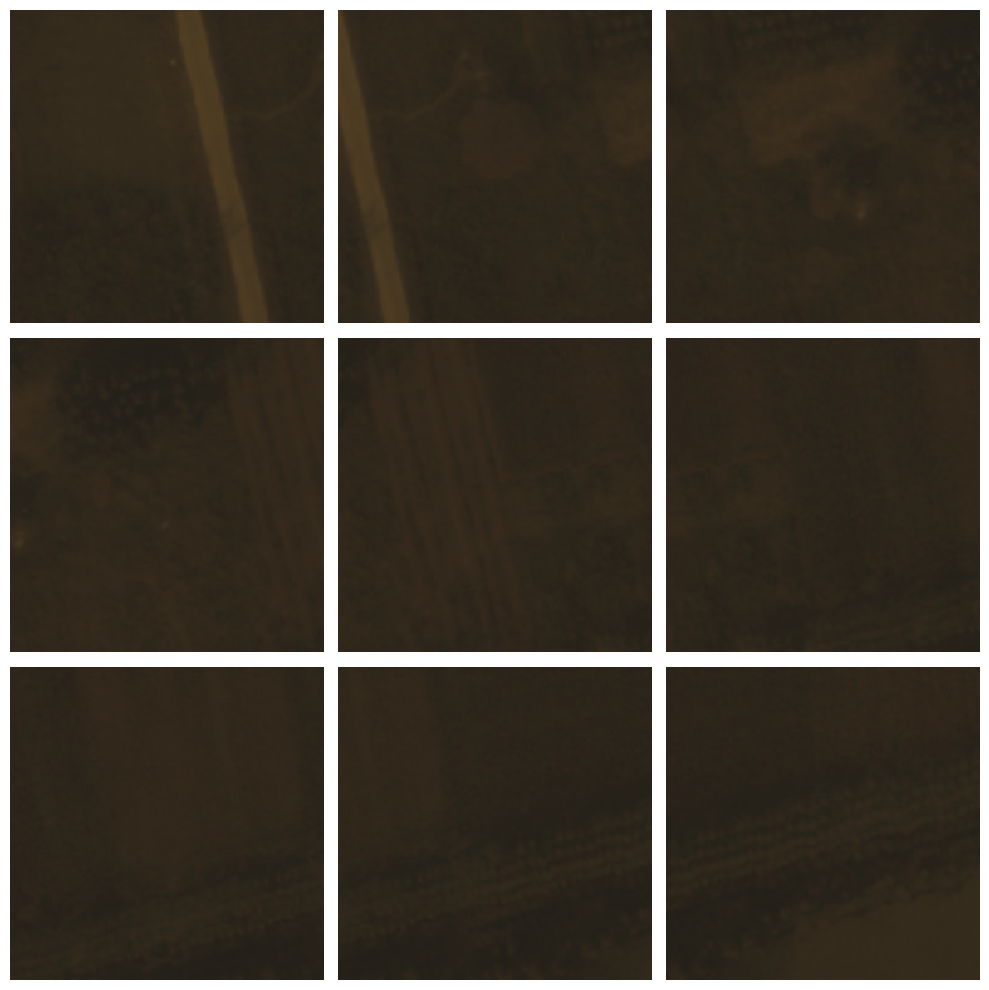

In [69]:
# ==================================================
# CELL 27
# PATCH VISUALIZATION
# ==================================================

plt.figure(figsize=(10,10))

for i in range(9):

    row, col = coords[i]

    patch = X_norm[
        row:row+PATCH_SIZE,
        col:col+PATCH_SIZE,
        :
    ]

    rgb = np.dstack([
    patch[:,:,50],
    patch[:,:,30],
    patch[:,:,10]
]).astype(np.float32)
    plt.subplot(3,3,i+1)

    plt.imshow(rgb)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [70]:
# ==================================================
# CELL 28
# FEDERATED CLIENTS
#
# Paper = 4 Clients
# Kaggle = 4 Clients
# ==================================================

NUM_CLIENTS = 4

print("Clients :", NUM_CLIENTS)

Clients : 4


In [71]:
# ==================================================
# CELL 29
# CLIENT SPLIT
#
# Paper:
# 4 Federated Clients
#
# Kaggle:
# Coordinate-Based Split
# ==================================================

client_coords = {}

coords_array = np.array(coords)

split_size = len(coords_array) // NUM_CLIENTS

for i in range(NUM_CLIENTS):

    start = i * split_size

    if i == NUM_CLIENTS - 1:
        end = len(coords_array)
    else:
        end = (i + 1) * split_size

    client_coords[i] = coords_array[start:end]

    print(
        f"Client {i+1}:",
        len(client_coords[i]),
        "patches"
    )

Client 1: 240 patches
Client 2: 240 patches
Client 3: 240 patches
Client 4: 240 patches


In [72]:
# ==================================================
# CELL 30
# SAVE CLIENT SPLIT
# ==================================================

np.save(
    "results/client_coords.npy",
    client_coords,
    allow_pickle=True
)

print("Client Split Saved")

Client Split Saved


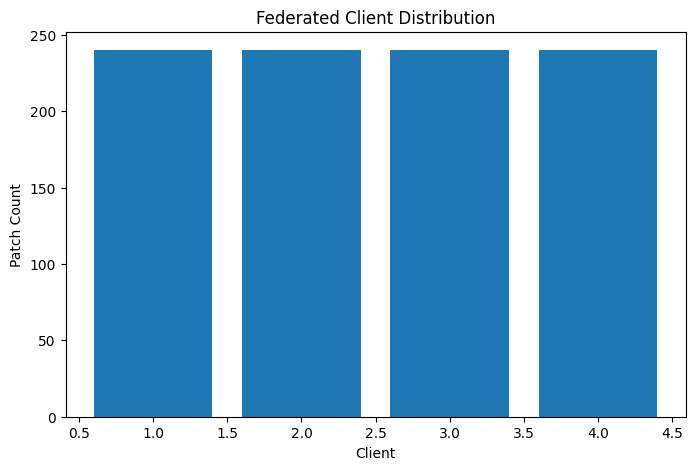

In [73]:
# ==================================================
# CELL 31
# CLIENT DISTRIBUTION
# ==================================================

sizes = [
    len(client_coords[i])
    for i in range(NUM_CLIENTS)
]

plt.figure(figsize=(8,5))

plt.bar(
    range(1, NUM_CLIENTS+1),
    sizes
)

plt.xlabel("Client")

plt.ylabel("Patch Count")

plt.title(
    "Federated Client Distribution"
)

plt.show()

In [74]:
# ==================================================
# CELL 32
# VERIFY CLIENT DATA
# ==================================================

client_id = 0

row, col = client_coords[client_id][0]

patch = X_norm[
    row:row+PATCH_SIZE,
    col:col+PATCH_SIZE,
    :
]

print(
    "Patch Shape:",
    patch.shape
)

Patch Shape: (128, 128, 256)


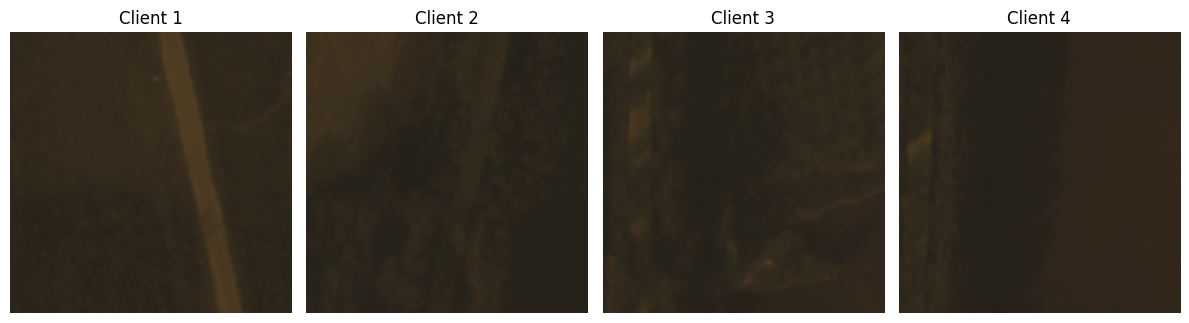

In [75]:
# ==================================================
# CELL 33
# CLIENT VISUALIZATION
# ==================================================

plt.figure(figsize=(12,4))

for i in range(NUM_CLIENTS):

    row, col = client_coords[i][0]

    patch = X_norm[
        row:row+PATCH_SIZE,
        col:col+PATCH_SIZE,
        :
    ]

    rgb = np.dstack([
        patch[:,:,50],
        patch[:,:,30],
        patch[:,:,10]
    ]).astype(np.float32)

    plt.subplot(1,4,i+1)

    plt.imshow(rgb)

    plt.title(
        f"Client {i+1}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [76]:
# ==================================================
# CELL 34
# PHASE 3 COMPLETE
# ==================================================

print("="*60)

print(
    "PHASE 3 COMPLETED"
)

print(
    "Federated Clients Created"
)

print(
    "Ready For Unmixing Autoencoder"
)

print("="*60)

PHASE 3 COMPLETED
Federated Clients Created
Ready For Unmixing Autoencoder


In [77]:
# ==================================================
# CELL 35
# PATCH MAJORITY CLASS
#
# Paper:
# Non-IID Federated Learning
#
# Purpose:
# Find dominant class in every patch
# ==================================================

patch_majority_class = []

for row, col in coords:

    label_patch = Y[
        row:row+PATCH_SIZE,
        col:col+PATCH_SIZE
    ]

    labels, counts = np.unique(
        label_patch,
        return_counts=True
    )

    majority = labels[np.argmax(counts)]

    patch_majority_class.append(
        majority
    )

print(
    "Processed:",
    len(patch_majority_class),
    "patches"
)

Processed: 960 patches


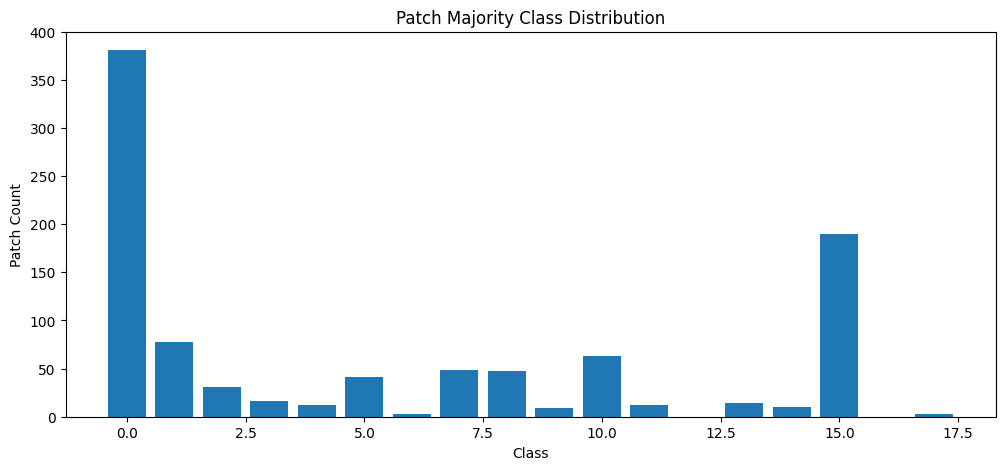

In [78]:
# ==================================================
# CELL 36
# CLASS DISTRIBUTION
# ==================================================

unique_classes, counts = np.unique(
    patch_majority_class,
    return_counts=True
)

plt.figure(figsize=(12,5))

plt.bar(
    unique_classes,
    counts
)

plt.xlabel("Class")

plt.ylabel("Patch Count")

plt.title(
    "Patch Majority Class Distribution"
)

plt.show()

In [79]:
# ==================================================
# CELL 37
# NON-IID CLIENT GROUPS
#
# Paper:
# Non-IID clients
#
# Kaggle:
# Class-based grouping
# ==================================================
client_coords = {
    0: [],
    1: [],
    2: [],
    3: []
}

client_labels = {
    0: [],
    1: [],
    2: [],
    3: []
}

for idx, cls in enumerate(
    patch_majority_class
):

    if cls <= 5:

        client_coords[0].append(
            coords[idx]
        )

        client_labels[0].append(
            cls
        )

    elif cls <= 10:

        client_coords[1].append(
            coords[idx]
        )

        client_labels[1].append(
            cls
        )

    elif cls <= 15:

        client_coords[2].append(
            coords[idx]
        )

        client_labels[2].append(
            cls
        )

    else:

        client_coords[3].append(
            coords[idx]
        )

        client_labels[3].append(
            cls
        )

In [80]:
# ==================================================
# CELL 38
# CLIENT STATISTICS
# ==================================================

for i in range(NUM_CLIENTS):

    print(
        f"Client {i+1}:",
        len(client_coords[i]),
        "patches"
    )

Client 1: 559 patches
Client 2: 172 patches
Client 3: 226 patches
Client 4: 3 patches


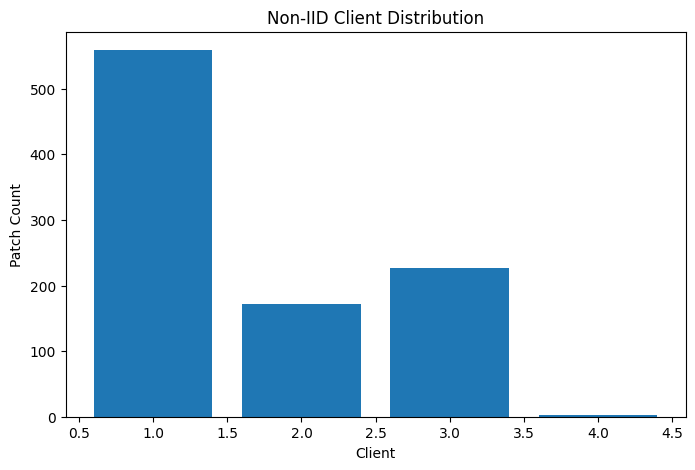

In [81]:
# ==================================================
# CELL 39
# NON-IID VISUALIZATION
# ==================================================

sizes = [
    len(client_coords[i])
    for i in range(NUM_CLIENTS)
]

plt.figure(figsize=(8,5))

plt.bar(
    range(1,5),
    sizes
)

plt.xlabel("Client")

plt.ylabel("Patch Count")

plt.title(
    "Non-IID Client Distribution"
)

plt.show()

In [82]:
# ==================================================
# CELL 40
# SAVE NON-IID CLIENTS
# ==================================================

np.save(
    "results/noniid_client_coords.npy",
    client_coords,
    allow_pickle=True
)

print(
    "Non-IID Client Split Saved"
)

Non-IID Client Split Saved


In [83]:
# ==================================================
# CELL 41
# HSI PATCH DATASET
#
# Updated for FedDA-HSI
# Returns:
#   patch + patch label
# ==================================================

import torch
from torch.utils.data import Dataset

class HSIPatchDataset(Dataset):

    def __init__(
        self,
        hsi,
        coords,
        labels,
        patch_size
    ):

        self.hsi = hsi
        self.coords = coords
        self.labels = labels
        self.patch_size = patch_size

    def __len__(self):

        return len(self.coords)

    def __getitem__(self, idx):

        row, col = self.coords[idx]

        patch = self.hsi[
            row:row+self.patch_size,
            col:col+self.patch_size,
            :
        ]

        patch = torch.tensor(
            patch,
            dtype=torch.float32
        )

        patch = patch.permute(
            2, 0, 1
        )

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return patch, label

In [84]:
# ==================================================
# CELL 42
# DATASET + DATALOADER
# ==================================================

train_dataset = HSIPatchDataset(
    X_norm,
    client_coords[0],
    client_labels[0],
    PATCH_SIZE
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

print(
    "Dataset Size:",
    len(train_dataset)
)

Dataset Size: 559


In [85]:
# ==================================================
# CELL 43
# ENCODER
#
# Paper:
# Endmembers = 5
#
# Kaggle:
# Same
# ==================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            256,
            128,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            128,
            64,
            kernel_size=3,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            64,
            NUM_ENDMEMBERS,
            kernel_size=1
        )

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        logits = self.conv3(x)

        logits = logits / 2.0

        abundances = F.softmax(
            logits,
            dim=1
        )

        return abundances




In [86]:
# ==================================================
# CELL 44
# DECODER
# ==================================================


import torch
import torch.nn as nn
import torch.nn.functional as F

class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.endmember_layer = nn.Conv2d(
            NUM_ENDMEMBERS,
            256,
            kernel_size=1,
            bias=False
        )

    def forward(self, abundance):

        # Non-negative endmembers
        weights = torch.relu(
            self.endmember_layer.weight
        )

        reconstruction = F.conv2d(
            abundance,
            weights
        )

        return reconstruction

In [87]:
# ==================================================
# CELL 45
# AUTOENCODER
# ==================================================
class UnmixingAutoencoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = Encoder()

        self.decoder = Decoder()

    def forward(self,x):

        abundances = self.encoder(x)

        reconstruction = self.decoder(
            abundances
        )

        return (
            abundances,
            reconstruction
        )

In [88]:
# ==================================================
# CELL 46
# MODEL
# ==================================================

unmixing_model = UnmixingAutoencoder().to(
    DEVICE
)

model = unmixing_model

In [89]:
decoder = unmixing_model.decoder

print(decoder)

Decoder(
  (endmember_layer): Conv2d(5, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
)


In [90]:
# ==================================================
# CELL 47
# LOSS
#
# Paper = 80 epochs
# Kaggle Safe = 30 epochs
# ==================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    unmixing_model.parameters(),
    lr=2e-4
)

In [91]:
# ==================================================
# CELL 48
# SANITY CHECK
# ==================================================

batch = next(iter(train_loader))

print(type(batch))
print(len(batch))

for i, item in enumerate(batch):
    print(f"Item {i} shape:", item.shape)

<class 'list'>
2
Item 0 shape: torch.Size([4, 256, 128, 128])
Item 1 shape: torch.Size([4])


In [92]:
# ==================================================
# CELL 49
# TRAINING FUNCTION
#
# Paper = 80 epochs
# Kaggle Safe = 30 epochs
# ==================================================

# ==================================================
# CELL 49
# TRAINING FUNCTION
# ==================================================
def train_autoencoder(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0

    for batch, _ in loader:

        batch = batch.to(DEVICE)

        optimizer.zero_grad()

        abundances, recon = model(batch)

        recon_loss = criterion(
            recon,
            batch
        )

        abundance_mean = abundances.mean(
            dim=(0,2,3)
        )

        target = torch.ones_like(
            abundance_mean
        ) / NUM_ENDMEMBERS

        balance_loss = (
            (abundance_mean - target) ** 2
        ).mean()

        loss = (
            recon_loss
            + 0.5 * balance_loss
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [93]:
# ==================================================
# CELL 50
# TRAIN AUTOENCODER
#
# Paper = 80 epochs
# Kaggle Safe = 30 epochs
# ==================================================

# Paper = 80
# Kaggle Safe = 30
UNMIX_EPOCHS = 30

loss_history = []

In [94]:
# ==================================================
# CELL 51
# TRAINING LOOP
# ==================================================

for epoch in range(
    UNMIX_EPOCHS
):

    loss = train_autoencoder(
        model,
        train_loader,
        criterion,
        optimizer
    )

    loss_history.append(
        loss
    )

    print(
        f"Epoch [{epoch+1}/{UNMIX_EPOCHS}] "
        f"Loss: {loss:.6f}"
    )

Epoch [1/30] Loss: 0.018311
Epoch [2/30] Loss: 0.016276
Epoch [3/30] Loss: 0.014637
Epoch [4/30] Loss: 0.013302
Epoch [5/30] Loss: 0.012193
Epoch [6/30] Loss: 0.011268
Epoch [7/30] Loss: 0.010484
Epoch [8/30] Loss: 0.009806
Epoch [9/30] Loss: 0.009221
Epoch [10/30] Loss: 0.008705
Epoch [11/30] Loss: 0.008258
Epoch [12/30] Loss: 0.007869
Epoch [13/30] Loss: 0.007515
Epoch [14/30] Loss: 0.007208
Epoch [15/30] Loss: 0.006935
Epoch [16/30] Loss: 0.006689
Epoch [17/30] Loss: 0.006479
Epoch [18/30] Loss: 0.006278
Epoch [19/30] Loss: 0.006100
Epoch [20/30] Loss: 0.005942
Epoch [21/30] Loss: 0.005797
Epoch [22/30] Loss: 0.005681
Epoch [23/30] Loss: 0.005557
Epoch [24/30] Loss: 0.005455
Epoch [25/30] Loss: 0.005360
Epoch [26/30] Loss: 0.005274
Epoch [27/30] Loss: 0.005196
Epoch [28/30] Loss: 0.005109
Epoch [29/30] Loss: 0.005049
Epoch [30/30] Loss: 0.004980


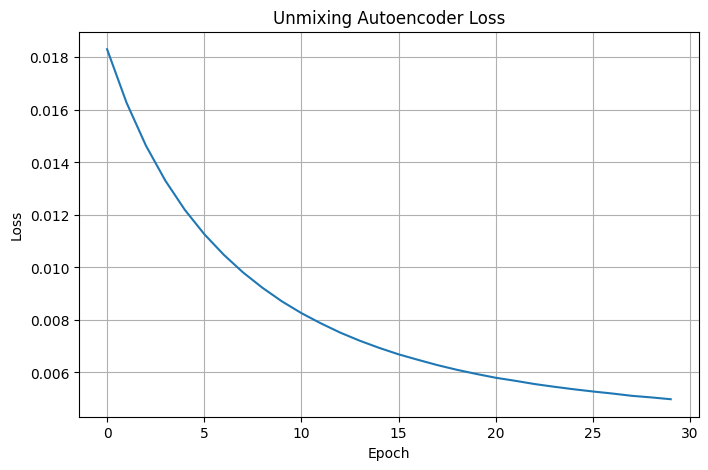

In [95]:
# ==================================================
# CELL 52
# LOSS CURVE
# ==================================================

plt.figure(figsize=(8,5))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Unmixing Autoencoder Loss"
)

plt.grid(True)

plt.show()

In [96]:
# ==================================================
# CELL 53
# SAVE MODEL
# ==================================================

torch.save(
    model.state_dict(),
    "models/unmixing_autoencoder.pt"
)

print(
    "Autoencoder Saved"
)

Autoencoder Saved


In [97]:
# ==================================================
# CELL 54
# EXTRACT ABUNDANCE MAPS
# ==================================================

model.eval()

with torch.no_grad():

    sample, labels = next(
        iter(train_loader)
    )

    sample = sample.to(
        DEVICE
    )

    abundances, recon = model(
        sample
    )

print(
    "Abundance Shape:",
    abundances.shape
)

Abundance Shape: torch.Size([4, 5, 128, 128])


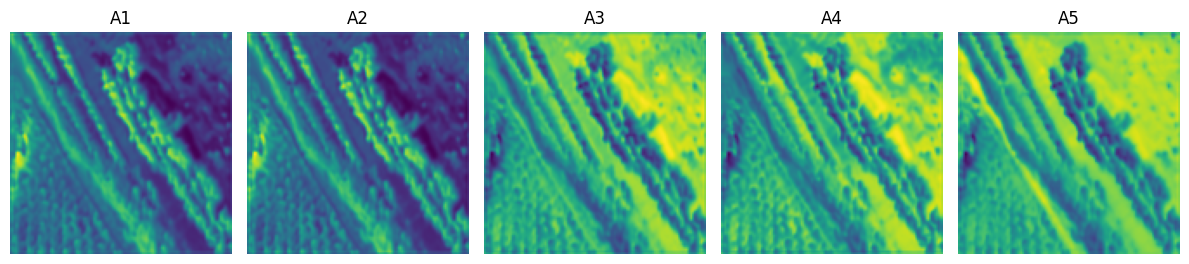

In [98]:
# ==================================================
# CELL 55
# VISUALIZE ABUNDANCE MAPS
# ==================================================

abundance = abundances[
    0
].cpu().numpy()

plt.figure(
    figsize=(12,3)
)

for i in range(NUM_ENDMEMBERS):

    plt.subplot(
        1,
        NUM_ENDMEMBERS,
        i+1
    )

    plt.imshow(
        abundance[i],
        cmap="viridis"
    )

    plt.title(
        f"A{i+1}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [99]:
print(abundances.shape)
print(abundances.min())
print(abundances.max())
print(abundances.mean())

torch.Size([4, 5, 128, 128])
tensor(0.1358, device='cuda:0')
tensor(0.2828, device='cuda:0')
tensor(0.2000, device='cuda:0')


In [100]:
for i in range(NUM_ENDMEMBERS):

    print(
        f"A{i+1}",
        abundances[:, i, :, :].mean().item()
    )

A1 0.2020287960767746
A2 0.19964289665222168
A3 0.2016884982585907
A4 0.19329231977462769
A5 0.20334748923778534


In [101]:
print(loss_history[-10:])

[0.005796823695501579, 0.0056811687586429925, 0.005557306347015713, 0.005454675781740141, 0.005359620146919042, 0.00527388547447377, 0.0051962782662095764, 0.005109041327211474, 0.005048638745211065, 0.004979502265008965]


In [102]:
with torch.no_grad():

    E = model.decoder.endmember_layer.weight

    print(E.shape)

    for i in range(NUM_ENDMEMBERS):

        print(
            f"EM {i+1}",
            E[:, i, 0, 0].min().item(),
            E[:, i, 0, 0].max().item(),
            E[:, i, 0, 0].mean().item()
        )

torch.Size([256, 5, 1, 1])
EM 1 -0.4429266154766083 0.9988710284233093 0.13329298794269562
EM 2 -0.4465683400630951 0.9250096678733826 0.10566805303096771
EM 3 -0.4454297721385956 1.021604299545288 0.045780569314956665
EM 4 -0.44064244627952576 0.9233895540237427 0.04767845571041107
EM 5 -0.44422802329063416 1.0871950387954712 0.05102125555276871


In [103]:
E = model.decoder.endmember_layer.weight.detach().cpu()

for i in range(NUM_ENDMEMBERS):

    em = E[:, i, 0, 0].numpy()

    print(
        f"EM{i+1}",
        "std =", em.std(),
        "min =", em.min(),
        "max =", em.max(),
        "mean =", em.mean()
    )

EM1 std = 0.37172148 min = -0.44292662 max = 0.998871 mean = 0.133293
EM2 std = 0.3617938 min = -0.44656834 max = 0.92500967 mean = 0.105668046
EM3 std = 0.34454063 min = -0.44542977 max = 1.0216043 mean = 0.04578057
EM4 std = 0.32430887 min = -0.44064245 max = 0.92338955 mean = 0.047678463
EM5 std = 0.35626936 min = -0.44422802 max = 1.087195 mean = 0.05102126


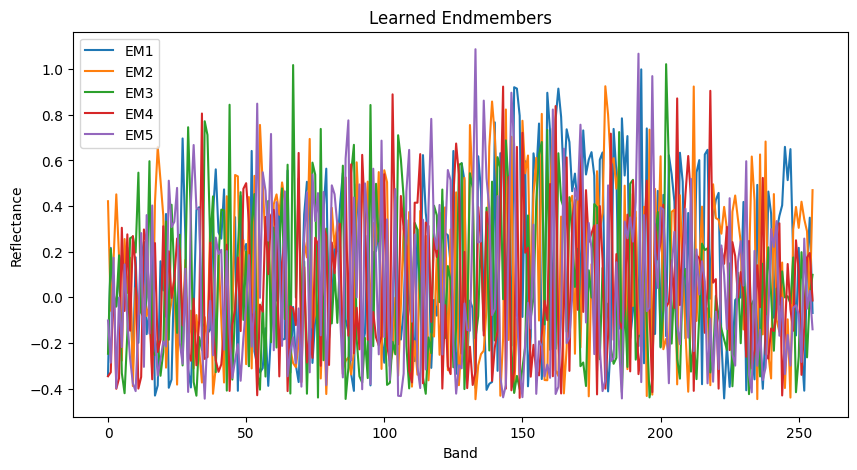

In [104]:
import matplotlib.pyplot as plt

E = model.decoder.endmember_layer.weight.detach().cpu()

plt.figure(figsize=(10,5))

for i in range(NUM_ENDMEMBERS):

    em = E[:, i, 0, 0].numpy()

    plt.plot(
        em,
        label=f"EM{i+1}"
    )

plt.legend()
plt.xlabel("Band")
plt.ylabel("Reflectance")
plt.title("Learned Endmembers")
plt.show()

In [105]:
with torch.no_grad():

    sample, labels = next(
        iter(train_loader)
    )

    sample = sample.to(DEVICE)

    abundances, recon = model(sample)

    mse = ((recon - sample)**2).mean()

    print(
        "MSE =",
        mse.item()
    )

MSE = 0.005133482627570629


In [106]:
# ==================================================
# CELL 56
# ABUNDANCE STATISTICS
# ==================================================

abundance_np = abundances.cpu().numpy()

for i in range(NUM_ENDMEMBERS):

    print(
        f"A{i+1}",
        abundance_np[:,i,:,:].mean()
    )

A1 0.20032708
A2 0.19879797
A3 0.2029248
A4 0.19318756
A5 0.20476258


In [107]:
# ==================================================
# CELL 62
# CHECK ABUNDANCES
# ==================================================
# ==================================================
# CELL 54
# EXTRACT ABUNDANCE MAPS
# ==================================================

batch = next(iter(train_loader))

print(type(batch))
print("Length =", len(batch))

for i, item in enumerate(batch):
    try:
        print(f"Item {i} shape =", item.shape)
    except:
        print(f"Item {i} =", type(item))

<class 'list'>
Length = 2
Item 0 shape = torch.Size([4, 256, 128, 128])
Item 1 shape = torch.Size([4])


In [108]:
# ==================================================
# CELL 63
# DIFFUSION PARAMETERS
#
# Paper = 2000 timesteps
# Kaggle Safe = 500 timesteps
# ==================================================

# Paper = 2000
# Kaggle Safe = 500
DIFFUSION_TIMESTEPS = 2000

BETA_START = 1e-6
BETA_END = 1e-2

print("Timesteps:", DIFFUSION_TIMESTEPS)

Timesteps: 2000


In [109]:
# ==================================================
# CELL 64
# NOISE SCHEDULE
# ==================================================

betas = torch.linspace(
    BETA_START,
    BETA_END,
    DIFFUSION_TIMESTEPS
).to(DEVICE)

alphas = 1.0 - betas

alpha_hat = torch.cumprod(
    alphas,
    dim=0
)

print("Schedule Ready")

Schedule Ready


In [110]:
# ==================================================
# CELL 65
# FORWARD DIFFUSION
#
# x0 = abundance map
# xt = noisy abundance map
# ==================================================

def forward_diffusion(
    x,
    t
):

    sqrt_alpha_hat = torch.sqrt(
        alpha_hat[t]
    )[:,None,None,None]

    sqrt_one_minus_alpha_hat = torch.sqrt(
        1 - alpha_hat[t]
    )[:,None,None,None]

    noise = torch.randn_like(x)

    xt = (
        sqrt_alpha_hat * x
        +
        sqrt_one_minus_alpha_hat * noise
    )

    return xt, noise

In [111]:
# ==================================================
# CELL 66
# TEST FORWARD DIFFUSION
# ==================================================

model.eval()

with torch.no_grad():

    sample, labels = next(
        iter(train_loader)
    )

    sample = sample.to(DEVICE)

    abundances, _ = model(sample)

t = torch.randint(
    0,
    DIFFUSION_TIMESTEPS,
    (abundances.shape[0],),
    device=DEVICE
)

xt, noise = forward_diffusion(
    abundances,
    t
)

print(
    "Original:",
    abundances.shape
)

print(
    "Noisy:",
    xt.shape
)

print(
    "Noise:",
    noise.shape
)

Original: torch.Size([4, 5, 128, 128])
Noisy: torch.Size([4, 5, 128, 128])
Noise: torch.Size([4, 5, 128, 128])


In [112]:
# ==================================================
# CELL 67
# DIFFUSION U-NET
#
# Paper:
# Larger U-Net
#
# Kaggle:
# Lightweight U-Net
# ==================================================

class ConditionalUNet(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.label_embed = nn.Embedding(
            num_classes,
            16
        )

        self.enc1 = nn.Sequential(
            nn.Conv2d(
                5 + 16,
                64,
                3,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                64,
                64,
                3,
                padding=1
            ),
            nn.ReLU()
        )

        self.enc2 = nn.Sequential(
            nn.Conv2d(
                64,
                128,
                3,
                padding=1
            ),
            nn.ReLU()
        )

        self.dec1 = nn.Sequential(
            nn.Conv2d(
                128,
                64,
                3,
                padding=1
            ),
            nn.ReLU()
        )

        self.final = nn.Conv2d(
            64,
            5,
            kernel_size=1
        )

    def forward(
        self,
        x,
        labels
    ):

        emb = self.label_embed(
            labels
        )

        emb = emb[:,:,None,None]

        emb = emb.expand(
            -1,
            -1,
            x.shape[2],
            x.shape[3]
        )

        x = torch.cat(
            [x, emb],
            dim=1
        )

        x1 = self.enc1(x)

        x2 = self.enc2(x1)

        x3 = self.dec1(x2)

        return self.final(x3)

In [113]:
# ==================================================
# CELL 68
# BUILD U-NET
# ==================================================
NUM_CLASSES = len(
    np.unique(Y[Y > 0])
)

unet = ConditionalUNet(
    NUM_CLASSES
).to(DEVICE)

In [114]:
# ==================================================
# CELL 69
# DIFFUSION SANITY CHECK
# ==================================================

sample, labels = next(
    iter(train_loader)
)

sample = sample.to(DEVICE)
labels = labels.to(DEVICE)

with torch.no_grad():

    abundances, _ = model(
        sample
    )

    t = torch.randint(
        0,
        DIFFUSION_TIMESTEPS,
        (abundances.shape[0],),
        device=DEVICE
    )

    xt, noise = forward_diffusion(
        abundances,
        t
    )

    pred_noise = unet(
        xt,
        labels
    )

print(
    "Input:",
    xt.shape
)

print(
    "Predicted Noise:",
    pred_noise.shape
)



Input: torch.Size([4, 5, 128, 128])
Predicted Noise: torch.Size([4, 5, 128, 128])


In [115]:
# ==================================================
# CELL 70
# DIFFUSION LOSS
# ==================================================

diffusion_criterion = nn.MSELoss()

diffusion_optimizer = torch.optim.Adam(
    unet.parameters(),
    lr=1e-4
)

In [116]:
# ==================================================
# CELL 71
# DIFFUSION TRAIN FUNCTION
#
# Paper = 2000 timesteps
# Kaggle Safe = 500 timesteps
# ==================================================
def train_diffusion_epoch(
    unet,
    autoencoder,
    loader,
    optimizer,
    criterion
):

    unet.train()

    epoch_loss = 0

    for batch, labels in loader:

        batch = batch.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.no_grad():

            abundances, _ = autoencoder(
                batch
            )

        t = torch.randint(
            0,
            DIFFUSION_TIMESTEPS,
            (abundances.shape[0],),
            device=DEVICE
        )

        xt, noise = forward_diffusion(
            abundances,
            t
        )

        pred_noise = unet(
            xt,
            labels
        )

        loss = criterion(
            pred_noise,
            noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)



In [117]:
# ==================================================
# CELL 72
# CLIENT 1 DATASET
# ==================================================

client0_dataset = HSIPatchDataset(
    X_norm,
    client_coords[0],
    client_labels[0],
    PATCH_SIZE
)

client0_loader = torch.utils.data.DataLoader(
    client0_dataset,
    batch_size=4,
    shuffle=True
)

print(
    "Client 1 Samples:",
    len(client0_dataset)
)

Client 1 Samples: 559


In [118]:
# ==================================================
# CELL 73
# DIFFUSION TRAINING
#
# Paper = 100+ epochs
# Kaggle Safe = 5 epochs
# ==================================================

DIFFUSION_EPOCHS = 30

diffusion_losses = []

In [119]:
# ==================================================
# CELL 78
# SAVE GLOBAL MODEL WEIGHTS
# ==================================================
# ==================================================
# RESET GLOBAL WEIGHTS FOR CONDITIONAL UNET
# ==================================================

global_model = ConditionalUNet(
    NUM_CLASSES
).to(DEVICE)

global_weights = global_model.state_dict()

print("Conditional UNet initialized")

Conditional UNet initialized


In [120]:
# ==================================================
# CELL 79
# FEDAVG AGGREGATION
#
# Paper:
# Server averages client weights
# ==================================================
def fedavg(client_models, client_sizes):

    total_samples = sum(client_sizes)

    avg_weights = {}

    for key in client_models[0]:

        avg_weights[key] = sum(
            client_sizes[i] *
            client_models[i][key]
            for i in range(len(client_models))
        ) / total_samples

    return avg_weights

In [121]:
# ==================================================
# CELL 80
# CREATE CLIENT MODELS
# ==================================================

# ==================================================
# CELL 80
# CREATE CLIENT MODELS
# ==================================================

client_models = []

for cid in range(NUM_CLIENTS):

    local_unet = ConditionalUNet(
        NUM_CLASSES
    ).to(DEVICE)

    local_unet.load_state_dict(
        global_weights
    )

    client_models.append(
        local_unet
    )

print(
    "Client Models:",
    len(client_models)
)

Client Models: 4


In [122]:
# ==================================================
# CELL 81
# CLIENT DATASETS
# ==================================================

client_loaders = []

for cid in range(NUM_CLIENTS):

    dataset = HSIPatchDataset(
        X_norm,
        client_coords[cid],
        client_labels[cid],
        PATCH_SIZE
    )

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=4,
        shuffle=True
    )

    client_loaders.append(
        loader
    )

    print(
        f"Client {cid+1}:",
        len(dataset)
    )

Client 1: 559
Client 2: 172
Client 3: 226
Client 4: 3


In [123]:
# ==================================================
# CELL 82
# LOCAL TRAINING
# ==================================================

# ==================================================
# CELL 82
# LOCAL TRAINING (IMPROVED)
#
# Original:
# LOCAL_EPOCHS = 1
#
# Kaggle Improved:
# LOCAL_EPOCHS = 2
# ==================================================

LOCAL_EPOCHS = 2

client_weights = []

for cid in range(NUM_CLIENTS):

    print(
        f"\nTraining Client {cid+1}"
    )

    local_model = client_models[cid]

    optimizer = torch.optim.Adam(
        local_model.parameters(),
        lr=1e-4
    )

    for local_epoch in range(LOCAL_EPOCHS):

        loss = train_diffusion_epoch(
            local_model,
            model,
            client_loaders[cid],
            optimizer,
            diffusion_criterion
        )

        print(
            f"Client {cid+1} | "
            f"Local Epoch {local_epoch+1}/{LOCAL_EPOCHS} | "
            f"Loss = {loss:.6f}"
        )

    client_weights.append(
        local_model.state_dict()
    )

print("\nLocal Training Completed")


Training Client 1
Client 1 | Local Epoch 1/2 | Loss = 0.729346
Client 1 | Local Epoch 2/2 | Loss = 0.221541

Training Client 2
Client 2 | Local Epoch 1/2 | Loss = 0.968285
Client 2 | Local Epoch 2/2 | Loss = 0.684047

Training Client 3
Client 3 | Local Epoch 1/2 | Loss = 0.938677
Client 3 | Local Epoch 2/2 | Loss = 0.586022

Training Client 4
Client 4 | Local Epoch 1/2 | Loss = 1.004869
Client 4 | Local Epoch 2/2 | Loss = 1.001759

Local Training Completed


In [124]:
# ==================================================
# CELL 82B
# FEDERATED ROUNDS
#
# Paper = 4 Rounds
# Kaggle Safe = 5 Rounds
# ==================================================
# ==================================================
# CELL 82B
# FEDERATED ROUNDS
#
# Paper = Many Rounds
# Kaggle Safe = 2 Rounds
# ==================================================
FED_ROUNDS = 4

for rnd in range(FED_ROUNDS):

    print(f"\n========== ROUND {rnd+1}/{FED_ROUNDS} ==========")

    client_weights = []
    client_sizes = []

    for cid in range(NUM_CLIENTS):

        print(f"\nTraining Client {cid+1}")

        # Local client model
        local_model = ConditionalUNet(
            NUM_CLASSES
        ).to(DEVICE)

        # Receive global model from server
        local_model.load_state_dict(
            global_weights
        )

        optimizer = torch.optim.Adam(
            local_model.parameters(),
            lr=1e-4
        )

        # Local training ONLY on client's data
        loss = train_diffusion_epoch(
            local_model,
            model,                  # <- changed
            client_loaders[cid],
            optimizer,
            diffusion_criterion
        )

        print(
            f"Client {cid+1} Loss: {loss:.4f}"
        )

        # Send ONLY parameters to server
        client_weights.append(
            local_model.state_dict()
        )

        client_sizes.append(
            len(client_loaders[cid].dataset)
        )

    # Server aggregation
    global_weights = fedavg(
        client_weights,
        client_sizes
    )

    # Update global model
    global_model.load_state_dict(
        global_weights
    )

    print(
        f"Round {rnd+1} Aggregation Complete"
    )

print("\nFederated Diffusion Training Done")

# Save GLOBAL federated model
torch.save(
    global_model.state_dict(),
    "models/federated_diffusion_unet.pt"
)

print("Federated Diffusion Model Saved")


========== ROUND 1/4 ==========

Training Client 1
Client 1 Loss: 0.7103

Training Client 2
Client 2 Loss: 0.9665

Training Client 3
Client 3 Loss: 0.9337

Training Client 4
Client 4 Loss: 1.0053
Round 1 Aggregation Complete

========== ROUND 2/4 ==========

Training Client 1
Client 1 Loss: 0.3336

Training Client 2
Client 2 Loss: 0.5151

Training Client 3
Client 3 Loss: 0.4545

Training Client 4
Client 4 Loss: 0.6919
Round 2 Aggregation Complete

========== ROUND 3/4 ==========

Training Client 1
Client 1 Loss: 0.1945

Training Client 2
Client 2 Loss: 0.3131

Training Client 3
Client 3 Loss: 0.2619

Training Client 4
Client 4 Loss: 0.4617
Round 3 Aggregation Complete

========== ROUND 4/4 ==========

Training Client 1
Client 1 Loss: 0.1392

Training Client 2
Client 2 Loss: 0.2042

Training Client 3
Client 3 Loss: 0.1894

Training Client 4
Client 4 Loss: 0.3234
Round 4 Aggregation Complete

Federated Diffusion Training Done
Federated Diffusion Model Saved


In [125]:

# =====================================================
# CELL 84
# SAVE FEDERATED GLOBAL U-NET
# =====================================================

global_model.load_state_dict(
    global_weights
)

torch.save(
    global_model.state_dict(),
    "models/federated_diffusion_unet.pt"
)

print("Federated Global U-Net Saved")

Federated Global U-Net Saved


In [126]:
# ==================================================
# CELL 85
# STAGE I COMPLETE
# ==================================================

print("="*60)

print(
    "STAGE I FEDERATED DIFFUSION COMPLETE"
)

print(
    "Ready For Stage II"
)

print(
    "Class-Aware Augmentation"
)

print("="*60)

STAGE I FEDERATED DIFFUSION COMPLETE
Ready For Stage II
Class-Aware Augmentation


In [127]:
print(model.decoder)

Decoder(
  (endmember_layer): Conv2d(5, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
)


In [128]:
# ==================================================
# CLIENT CLASS DISTRIBUTION
# ==================================================

from collections import Counter

client_class_stats = {}

for cid in range(NUM_CLIENTS):

    labels = []

    for r, c in client_coords[cid]:
        labels.append(Y[r, c])

    labels = np.array(labels)

    client_class_stats[cid] = Counter(labels)

    print(f"\nClient {cid+1}")

    print(client_class_stats[cid])


Client 1
Counter({np.uint8(0): 334, np.uint8(1): 66, np.uint8(2): 31, np.uint8(15): 24, np.uint8(5): 21, np.uint8(10): 19, np.uint8(3): 16, np.uint8(7): 12, np.uint8(8): 11, np.uint8(13): 6, np.uint8(4): 6, np.uint8(19): 5, np.uint8(9): 2, np.uint8(14): 2, np.uint8(11): 1, np.uint8(16): 1, np.uint8(12): 1, np.uint8(17): 1})

Client 2
Counter({np.uint8(10): 50, np.uint8(0): 37, np.uint8(8): 36, np.uint8(7): 24, np.uint8(5): 10, np.uint8(9): 6, np.uint8(6): 3, np.uint8(11): 2, np.uint8(4): 2, np.uint8(15): 1, np.uint8(13): 1})

Client 3
Counter({np.uint8(15): 137, np.uint8(0): 57, np.uint8(13): 8, np.uint8(11): 6, np.uint8(14): 5, np.uint8(12): 4, np.uint8(3): 3, np.uint8(4): 2, np.uint8(1): 2, np.uint8(17): 1, np.uint8(18): 1})

Client 4
Counter({np.uint8(0): 2, np.uint8(17): 1})


In [129]:
# ==================================================
# RARE CLASS DETECTION
# ==================================================

RARE_THRESHOLD = 5

rare_classes = {}

for cid in range(NUM_CLIENTS):

    rare_classes[cid] = []

    for cls, count in client_class_stats[cid].items():

        if cls == 0:
            continue

        if count < RARE_THRESHOLD:

            rare_classes[cid].append(
                int(cls)
            )

    print(
        f"Client {cid+1} Rare Classes:"
    )

    print(
        rare_classes[cid]
    )

Client 1 Rare Classes:
[9, 11, 14, 16, 12, 17]
Client 2 Rare Classes:
[11, 15, 13, 4, 6]
Client 3 Rare Classes:
[12, 4, 3, 17, 18, 1]
Client 4 Rare Classes:
[17]


In [130]:
# ==================================================
# LABEL MAPPING
# ==================================================

CLASS_IDS = sorted(
    np.unique(Y[Y > 0])
)

label_map = {
    cls: idx
    for idx, cls in enumerate(CLASS_IDS)
}

print("NUM_CLASSES =", NUM_CLASSES)
print("CLASS_IDS =", CLASS_IDS)
print("LABEL MAP =")

for k, v in label_map.items():
    print(f"{k} -> {v}")

NUM_CLASSES = 19
CLASS_IDS = [np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19)]
LABEL MAP =
1 -> 0
2 -> 1
3 -> 2
4 -> 3
5 -> 4
6 -> 5
7 -> 6
8 -> 7
9 -> 8
10 -> 9
11 -> 10
12 -> 11
13 -> 12
14 -> 13
15 -> 14
16 -> 15
17 -> 16
18 -> 17
19 -> 18


In [131]:
print(label_map)

print("Max label index:",
      max(label_map.values()))

print("NUM_CLASSES:",
      NUM_CLASSES)

{np.uint8(1): 0, np.uint8(2): 1, np.uint8(3): 2, np.uint8(4): 3, np.uint8(5): 4, np.uint8(6): 5, np.uint8(7): 6, np.uint8(8): 7, np.uint8(9): 8, np.uint8(10): 9, np.uint8(11): 10, np.uint8(12): 11, np.uint8(13): 12, np.uint8(14): 13, np.uint8(15): 14, np.uint8(16): 15, np.uint8(17): 16, np.uint8(18): 17, np.uint8(19): 18}
Max label index: 18
NUM_CLASSES: 19


In [132]:
# ==================================================
# TEST FEDERATED CONDITIONAL UNET
# ==================================================

test_cls = rare_classes[0][0]

print("Testing Class:", test_cls)

noise = torch.randn(
    1,
    NUM_ENDMEMBERS,      # 5
    PATCH_SIZE,
    PATCH_SIZE,
    device=DEVICE
)

label = torch.tensor(
    [label_map[int(test_cls)]],
    dtype=torch.long,
    device=DEVICE
)

global_model.eval()

with torch.no_grad():

    output = global_model(
        noise,
        label
    )

print("Output Shape:", output.shape)

Testing Class: 9
Output Shape: torch.Size([1, 5, 128, 128])


In [133]:
print("NUM_CLASSES =", NUM_CLASSES)

print("Unique labels:")
print(sorted(np.unique(Y[Y > 0])))

NUM_CLASSES = 19
Unique labels:
[np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19)]


In [134]:
# ==================================================
# SYNTHETIC ABUNDANCE GENERATION (DP VERSION)
# ==================================================

DP_SIGMA = 0.05

synthetic_abundance = {}

global_model.eval()

for cid in range(NUM_CLIENTS):

    synthetic_abundance[cid] = []

    for cls in rare_classes[cid]:

        print(f"Generating Class {cls}")

        for _ in range(50):

            noise = torch.randn(
                1,
                NUM_ENDMEMBERS,
                PATCH_SIZE,
                PATCH_SIZE,
                device=DEVICE
            )

            label = torch.tensor(
                [label_map[int(cls)]],
                dtype=torch.long,
                device=DEVICE
            )

            with torch.no_grad():

                abundance = global_model(
                    noise,
                    label
                )

                # Differential Privacy Noise
                dp_noise = (
                    torch.randn_like(abundance)
                    * DP_SIGMA
                )

                abundance = abundance + dp_noise

                abundance = torch.clamp(
                    abundance,
                    min=0.0
                )

            synthetic_abundance[cid].append(
                (
                    abundance.cpu(),
                    cls
                )
            )

print("Synthetic abundance generation complete")

Generating Class 9
Generating Class 11
Generating Class 14
Generating Class 16
Generating Class 12
Generating Class 17
Generating Class 11
Generating Class 15
Generating Class 13
Generating Class 4
Generating Class 6
Generating Class 12
Generating Class 4
Generating Class 3
Generating Class 17
Generating Class 18
Generating Class 1
Generating Class 17
Synthetic abundance generation complete


In [135]:
for cid in synthetic_abundance:
    print(
        f"Client {cid}:",
        len(synthetic_abundance[cid])
    )

Client 0: 300
Client 1: 250
Client 2: 300
Client 3: 50


In [136]:
decoder = model.decoder
decoder.eval()

abundance, cls = synthetic_abundance[0][0]

with torch.no_grad():

    hsi = decoder(
        abundance.to(DEVICE)
    )

print(hsi.shape)
print(cls)

torch.Size([1, 256, 128, 128])
9


In [137]:
# ==================================================
# SYNTHETIC HSI GENERATION
# ==================================================

synthetic_hsi = []

decoder = model.decoder
decoder.eval()

for cid in synthetic_abundance:

    for abundance, cls in synthetic_abundance[cid]:

        with torch.no_grad():

            hsi = decoder(
                abundance.to(DEVICE)
            )

        synthetic_hsi.append(
            (
                hsi.cpu(),
                cls
            )
        )

print(
    "Total Synthetic HSI:",
    len(synthetic_hsi)
)

Total Synthetic HSI: 900


In [138]:
# ==================================================
# CONVERT SYNTHETIC HSI -> 7x7 PATCHES
# ==================================================

MAX_SYNTH_CUBES = 200

extra_x = []
extra_y = []

for cube, cls in synthetic_hsi[:MAX_SYNTH_CUBES]:

    cube = cube.squeeze(0).cpu().numpy()   # (256,128,128)

    for _ in range(5):                     # 5 patches per cube

        r = np.random.randint(0, 122)
        c = np.random.randint(0, 122)

        patch = cube[:, r:r+7, c:c+7]      # (256,7,7)

        extra_x.append(
            patch.astype(np.float32)
        )

        extra_y.append(
            cls - 1                        # match pixel_y labels
        )

print("Synthetic patches:", len(extra_x))
print("Synthetic labels :", len(extra_y))

print("Patch shape:", extra_x[0].shape)
print("Label range:",
      min(extra_y),
      max(extra_y))

Synthetic patches: 1000
Synthetic labels : 1000
Patch shape: (256, 7, 7)
Label range: 8 15


In [139]:
batch = next(iter(train_loader))

print(type(batch))
print(len(batch))

for i, item in enumerate(batch):
    try:
        print(i, item.shape)
    except:
        print(i, type(item))

<class 'list'>
2
0 torch.Size([4, 256, 128, 128])
1 torch.Size([4])


In [140]:
print(type(dataset.hsi))

X = dataset.hsi

print(type(X))
print(X.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(1580, 3750, 256)


In [141]:
print(type(Y))
print(Y.shape)
print(np.unique(Y))

<class 'numpy.ndarray'>
(1580, 3750)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [142]:
print(np.count_nonzero(Y))

3341881


In [143]:
from collections import Counter

labels = Y[Y > 0].flatten()

print("Labeled pixels:", len(labels))
print(Counter(labels))

Labeled pixels: 3341881
Counter({np.uint8(15): 986139, np.uint8(1): 426138, np.uint8(10): 372708, np.uint8(7): 296538, np.uint8(8): 276755, np.uint8(5): 197218, np.uint8(2): 187425, np.uint8(3): 124862, np.uint8(4): 91518, np.uint8(13): 85547, np.uint8(14): 68885, np.uint8(11): 67210, np.uint8(9): 44232, np.uint8(12): 29763, np.uint8(17): 27178, np.uint8(19): 26140, np.uint8(6): 19663, np.uint8(16): 7456, np.uint8(18): 6506})


In [144]:
TARGET_TOTAL = 120000

TOTAL_LABELS = np.sum(Y > 0)

selected_pixels = []

for cls in range(1, 20):

    coords = np.argwhere(Y == cls)

    n = int(
        len(coords) / TOTAL_LABELS * TARGET_TOTAL
    )

    n = max(100, n)

    idx = np.random.choice(
        len(coords),
        min(n, len(coords)),
        replace=False
    )

    selected_pixels.extend(
        [(r, c, cls) for r, c in coords[idx]]
    )

print("Selected pixels:", len(selected_pixels))

Selected pixels: 119991


In [145]:
from collections import Counter

selected_labels = [cls for _, _, cls in selected_pixels]

print(Counter(selected_labels))

Counter({15: 35410, 1: 15301, 10: 13383, 7: 10648, 8: 9937, 5: 7081, 2: 6730, 3: 4483, 4: 3286, 13: 3071, 14: 2473, 11: 2413, 9: 1588, 12: 1068, 17: 975, 19: 938, 6: 706, 16: 267, 18: 233})


In [146]:
print(type(model))
print(model)

<class '__main__.UnmixingAutoencoder'>
UnmixingAutoencoder(
  (encoder): Encoder(
    (conv1): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv3): Conv2d(64, 5, kernel_size=(1, 1), stride=(1, 1))
  )
  (decoder): Decoder(
    (endmember_layer): Conv2d(5, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
)


In [147]:
PIXEL_PATCH = 7
HALF = PIXEL_PATCH // 2

padded_X = np.pad(
    X,
    ((HALF, HALF),
     (HALF, HALF),
     (0, 0)),
    mode="reflect"
)

pixel_x = []
pixel_y = []

for r, c, cls in selected_pixels:

    patch = padded_X[
        r:r+PIXEL_PATCH,
        c:c+PIXEL_PATCH,
        :
    ]

    patch = np.transpose(
        patch,
        (2, 0, 1)
    )

    pixel_x.append(
        patch.astype(np.float32)
    )

    pixel_y.append(
        cls - 1
    )

print("Patches:", len(pixel_x))
print("Labels :", len(pixel_y))
print("Patch shape:", pixel_x[0].shape)

Patches: 119991
Labels : 119991
Patch shape: (256, 7, 7)


In [148]:
print(pixel_x[0].shape)
print(min(pixel_y), max(pixel_y))

(256, 7, 7)
0 18


In [149]:
from sklearn.model_selection import train_test_split

# ==================================================
# SPLIT REAL DATA FIRST
# ==================================================

print("Original Samples :", len(pixel_x))
print("Synthetic Samples:", len(extra_x))

# 40% Train, 30% Val, 30% Test
X_train, X_temp, y_train, y_temp = train_test_split(
    pixel_x,
    pixel_y,
    test_size=0.60,
    random_state=42,
    stratify=pixel_y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ==================================================
# ADD SYNTHETIC ONLY TO TRAIN
# ==================================================

X_train = list(X_train)
y_train = list(y_train)

X_train.extend(extra_x)
y_train.extend(extra_y)

print("\nAfter Adding Synthetic Samples")

print("Train :", len(X_train))
print("Val   :", len(X_val))
print("Test  :", len(X_test))

Original Samples : 119991
Synthetic Samples: 1000

After Adding Synthetic Samples
Train : 48996
Val   : 35997
Test  : 35998


In [150]:
import torch
from torch.utils.data import Dataset

class PixelDataset(Dataset):

    def __init__(self, X, y):

        self.X = X
        self.y = y

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        x = torch.tensor(
            self.X[idx],
            dtype=torch.float32
        )

        # 3D CNN input:
        # (1, Spectral, Height, Width)

        x = x.unsqueeze(0)

        y = torch.tensor(
            self.y[idx],
            dtype=torch.long
        )

        return x, y

In [151]:
train_dataset = PixelDataset(
    X_train,
    y_train
)

val_dataset = PixelDataset(
    X_val,
    y_val
)

test_dataset = PixelDataset(
    X_test,
    y_test
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

48996
35997
35998


In [152]:
print("Train:", len(X_train))
print("Val  :", len(X_val))
print("Test :", len(X_test))

print("Train classes:", len(np.unique(y_train)))
print("Val classes  :", len(np.unique(y_val)))
print("Test classes :", len(np.unique(y_test)))

print("Train labels:", np.unique(y_train))
print("Val labels  :", np.unique(y_val))
print("Test labels :", np.unique(y_test))

Train: 48996
Val  : 35997
Test : 35998
Train classes: 19
Val classes  : 19
Test classes : 19
Train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
Val labels  : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
Test labels : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


In [153]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [154]:
x, y = next(iter(train_loader))

print(x.shape)
print(y.shape)

torch.Size([32, 1, 256, 7, 7])
torch.Size([32])


In [155]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class HSI3DCNN_Attention_Transformer(nn.Module):

    def __init__(self, num_classes=19):

        super().__init__()

        # ==========================================
        # 3D CNN FEATURE EXTRACTOR
        # ==========================================
        self.features = nn.Sequential(

            nn.Conv3d(
                1, 8,
                kernel_size=(7,3,3),
                padding=(3,1,1)
            ),
            nn.BatchNorm3d(8),
            nn.ReLU(),

            nn.MaxPool3d((2,2,2)),

            nn.Conv3d(
                8, 16,
                kernel_size=(5,3,3),
                padding=(2,1,1)
            ),
            nn.BatchNorm3d(16),
            nn.ReLU(),

            nn.MaxPool3d((2,2,2)),

            nn.Conv3d(
                16, 32,
                kernel_size=(3,3,3),
                padding=1
            ),
            nn.BatchNorm3d(32),
            nn.ReLU()
        )

        # ==========================================
        # CHANNEL (SPECTRAL) ATTENTION
        # ==========================================
        self.channel_attention = nn.Sequential(

            nn.AdaptiveAvgPool3d(1),

            nn.Conv3d(
                32,
                8,
                kernel_size=1
            ),

            nn.ReLU(),

            nn.Conv3d(
                8,
                32,
                kernel_size=1
            ),

            nn.Sigmoid()
        )

        # ==========================================
        # SPATIAL ATTENTION
        # ==========================================
        self.spatial_attention = nn.Sequential(

            nn.Conv3d(
                32,
                1,
                kernel_size=3,
                padding=1
            ),

            nn.Sigmoid()
        )

        # ==========================================
        # SPECTRAL-SPATIAL TRANSFORMER
        # ==========================================
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=32,
            nhead=4,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        # ==========================================
        # PROJECTION HEAD
        # (Used ONLY for Supervised Contrastive Loss)
        # ==========================================
        self.projection_head = nn.Sequential(

            nn.Linear(32, 128),
            nn.ReLU(),

            nn.Linear(128, 128)
        )

        # ==========================================
        # CLASSIFIER
        # ==========================================
        self.classifier = nn.Sequential(

            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        # ==========================================
        # 3D CNN
        # ==========================================
        x = self.features(x)

        # ==========================================
        # CHANNEL ATTENTION
        # ==========================================
        ca = self.channel_attention(x)
        x = x * ca

        # ==========================================
        # SPATIAL ATTENTION
        # ==========================================
        sa = self.spatial_attention(x)
        x = x * sa

        # ==========================================
        # TOKENIZATION
        # ==========================================
        B, C, D, H, W = x.shape

        x = x.view(B, C, D * H * W)

        x = x.permute(0, 2, 1)

        # ==========================================
        # TRANSFORMER
        # ==========================================
        x = self.transformer(x)

        # ==========================================
        # GLOBAL TOKEN POOLING
        # ==========================================
        features = x.mean(dim=1)

        # ==========================================
        # PROJECTION EMBEDDING
        # ==========================================
        projection = self.projection_head(features)

        projection = F.normalize(
            projection,
            dim=1
        )

        # ==========================================
        # CLASSIFICATION
        # ==========================================
        logits = self.classifier(features)

        return logits, projection

In [156]:
# ==================================================
# CELL XX
# STAGE 8
# SUPERVISED CONTRASTIVE LOSS
#
# Purpose:
# Learn discriminative feature embeddings by
# pulling samples of the same class together
# while pushing different classes apart.
#
# Reference:
# Supervised Contrastive Learning (NeurIPS 2020)
# ==================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class SupConLoss(nn.Module):

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):

        device = features.device

        labels = labels.contiguous().view(-1, 1)

        mask = torch.eq(
            labels,
            labels.T
        ).float().to(device)

        features = F.normalize(
            features,
            dim=1
        )

        similarity = torch.matmul(
            features,
            features.T
        ) / self.temperature

        logits_max, _ = torch.max(
            similarity,
            dim=1,
            keepdim=True
        )

        logits = similarity - logits_max.detach()

        logits_mask = torch.ones_like(mask)

        logits_mask.fill_diagonal_(0)

        mask = mask * logits_mask

        exp_logits = torch.exp(logits) * logits_mask

        log_prob = logits - torch.log(
            exp_logits.sum(
                dim=1,
                keepdim=True
            ) + 1e-12
        )

        mean_log_prob_pos = (
            mask * log_prob
        ).sum(1) / (
            mask.sum(1) + 1e-12
        )

        loss = -mean_log_prob_pos.mean()

        return loss


supcon_criterion = SupConLoss(
    temperature=0.07
)

print("Supervised Contrastive Loss Initialized")

Supervised Contrastive Loss Initialized


In [157]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HSI3DCNN_Attention_Transformer(
    num_classes=19
).to(device)

In [158]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
     lr=3e-4
)

In [164]:
x, y = next(iter(train_loader))

x = x.to(DEVICE)

with torch.no_grad():

    logits, projection = model(x)

print("Logits Shape     :", logits.shape)
print("Projection Shape :", projection.shape)

Logits Shape     : torch.Size([32, 19])
Projection Shape : torch.Size([32, 128])


In [160]:
# ==================================================
# CELL 119
# CLASSIFIER TRAINING
#
# Stage 8
# Supervised Contrastive Learning
# ==================================================

EPOCHS = 80

best_val_acc = 0

LAMBDA_SUPCON = 0.10

for epoch in range(EPOCHS):

    # =====================
    # TRAIN
    # =====================

    model.train()

    train_correct = 0
    train_total = 0

    for x, y in train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        # --------------------------
        # Forward
        # --------------------------
        logits, projection = model(x)

        ce_loss = criterion(
            logits,
            y
        )

        supcon_loss = supcon_criterion(
            projection,
            y
        )

        loss = (
            ce_loss +
            LAMBDA_SUPCON * supcon_loss
        )

        loss.backward()

        optimizer.step()

        pred = logits.argmax(1)

        train_correct += (
            pred == y
        ).sum().item()

        train_total += y.size(0)

    train_acc = (
        100 * train_correct /
        train_total
    )

    # =====================
    # VALIDATION
    # =====================

    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits, projection = model(x)

            pred = logits.argmax(1)

            val_correct += (
                pred == y
            ).sum().item()

            val_total += y.size(0)

    val_acc = (
        100 * val_correct /
        val_total
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_3dcnn.pt"
        )

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch 01 | Train Acc: 45.23% | Val Acc: 48.02%
Epoch 02 | Train Acc: 52.73% | Val Acc: 56.00%
Epoch 03 | Train Acc: 56.75% | Val Acc: 55.46%
Epoch 04 | Train Acc: 58.97% | Val Acc: 59.74%
Epoch 05 | Train Acc: 62.25% | Val Acc: 53.75%
Epoch 06 | Train Acc: 64.37% | Val Acc: 50.46%
Epoch 07 | Train Acc: 66.82% | Val Acc: 66.17%
Epoch 08 | Train Acc: 68.73% | Val Acc: 62.26%
Epoch 09 | Train Acc: 70.31% | Val Acc: 72.64%
Epoch 10 | Train Acc: 71.74% | Val Acc: 74.60%
Epoch 11 | Train Acc: 72.86% | Val Acc: 74.98%
Epoch 12 | Train Acc: 73.99% | Val Acc: 68.44%
Epoch 13 | Train Acc: 75.14% | Val Acc: 73.32%
Epoch 14 | Train Acc: 75.48% | Val Acc: 72.92%
Epoch 15 | Train Acc: 76.13% | Val Acc: 76.90%
Epoch 16 | Train Acc: 77.09% | Val Acc: 60.40%
Epoch 17 | Train Acc: 77.57% | Val Acc: 81.33%
Epoch 18 | Train Acc: 78.34% | Val Acc: 79.51%
Epoch 19 | Train Acc: 78.59% | Val Acc: 78.16%
Epoch 20 | Train Acc: 79.19% | Val Acc: 81.45%
Epoch 21 | Train Acc: 79.65% | Val Acc: 81.96%
Epoch 22 | Tr

In [165]:
model.load_state_dict(
    torch.load(
        "best_3dcnn.pt"
    )
)

<All keys matched successfully>

In [166]:
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix
)

import numpy as np

model.eval()

all_pred = []
all_true = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(DEVICE)

        # Model now returns (logits, projection)
        logits, _ = model(x)

        pred = logits.argmax(dim=1)

        all_pred.extend(
            pred.cpu().numpy()
        )

        all_true.extend(
            y.numpy()
        )

OA = accuracy_score(
    all_true,
    all_pred
)

cm = confusion_matrix(
    all_true,
    all_pred
)

per_class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-12)

AA = np.mean(per_class_acc)

Kappa = cohen_kappa_score(
    all_true,
    all_pred
)

print(f"OA: {OA*100:.2f}%")
print(f"AA: {AA*100:.2f}%")
print(f"Kappa: {Kappa:.4f}")

OA: 90.72%
AA: 81.15%
Kappa: 0.8917


In [167]:
print(len(X_train))
print(len(X_val))
print(len(X_test))
print(X_train.shape)

48996
35997
35998


AttributeError: 'list' object has no attribute 'shape'

In [168]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(
    all_true,
    all_pred
)

cm_df = pd.DataFrame(cm)

print(cm_df)

      0     1     2    3     4    5     6     7    8     9    10   11   12  \
0   4584     0     0    0     0    0     1     0    0     0    0    0    0   
1      5  1982     0    1     7    1    12     0    0     0    1    0    5   
2      0     0  1329    0     1    0     0     0    0     6    1    0    0   
3      1    14     0  766    18    2    22    31    0     9   17   10    7   
4     10     0     0    6  2021    5    20    11    0     3    5    1    1   
5      1     0     0    0    38  164     4     0    0     0    0    0    1   
6      2     0     0    7    80    1  2798   133    0    47    1    0    6   
7      0     0     0   27    28    1    96  2506   37   154    4    0    0   
8      0     0     0    0     1    1     8    44  377    17    2    0    2   
9      0     0     0    4    25    3    34    51   19  3683    5    1   11   
10     4     2     0    2     2    0     3     3    0     3  600    1    3   
11    10     3     0    1     9    0    15     3    0    19    3

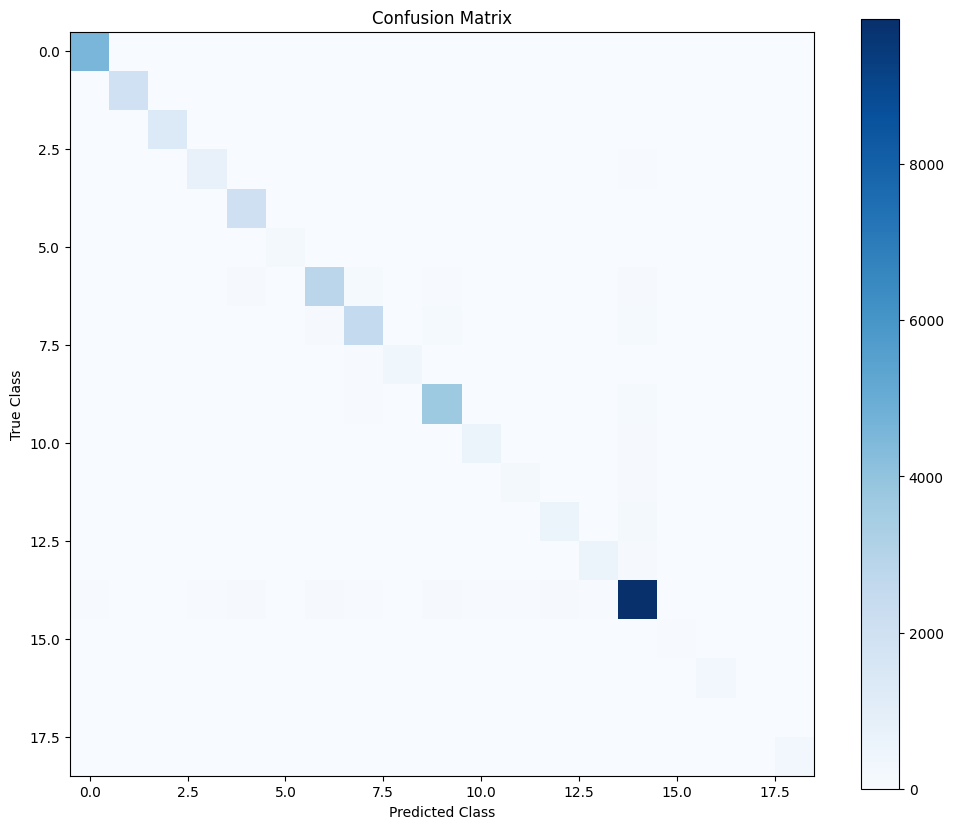

In [169]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.imshow(cm, cmap="Blues")

plt.colorbar()

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

plt.show()

In [170]:
cm = confusion_matrix(all_true, all_pred)

per_class_acc = cm.diagonal() / cm.sum(axis=1)

print("Per-class accuracy:")
print(per_class_acc)

print("AA =", np.mean(per_class_acc))

Per-class accuracy:
[0.99847528 0.9816741  0.98810409 0.77687627 0.95105882 0.77725118
 0.87574335 0.8406575  0.79035639 0.91731009 0.82872928 0.5
 0.6514658  0.82345013 0.92855126 0.4875     0.96232877 0.4
 0.93950178]
AA = 0.8115281097200016


In [171]:
import numpy as np

class_acc = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_acc):
    print(
        f"Class {i}: {acc*100:.2f}%"
    )

print(
    f"\nAverage Accuracy: {np.mean(class_acc)*100:.2f}%"
)

Class 0: 99.85%
Class 1: 98.17%
Class 2: 98.81%
Class 3: 77.69%
Class 4: 95.11%
Class 5: 77.73%
Class 6: 87.57%
Class 7: 84.07%
Class 8: 79.04%
Class 9: 91.73%
Class 10: 82.87%
Class 11: 50.00%
Class 12: 65.15%
Class 13: 82.35%
Class 14: 92.86%
Class 15: 48.75%
Class 16: 96.23%
Class 17: 40.00%
Class 18: 93.95%

Average Accuracy: 81.15%


In [172]:
cm_df.to_csv(
    "confusion_matrix.csv",
    index=False
)

print("Saved confusion_matrix.csv")

Saved confusion_matrix.csv


In [ ]:
print(class_acc)